## 📔Projekat - Analiza različitim dijagramima
U ovom fajlu će se nalaziti raličiti zadaci iz poslednje jedinice 3. modua
Radićemo različite zadatke pomoću:
- matplotlib-a i seaborn-a (logično)
- histograma i KDE linija
- kutijastih dijagrama
- dijagrama rasejanja
- toplotnih mapa

## ✍️Uvod
Prvo i osnovno **uvozimo biblioteke** i definišemo DataFrame:

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv("books.csv")

## ⚙️Provera
Čisto radi reda, **proverićemo DataFrame** i skup podataka koji imamo prikazivanje prvih 5 redova:


In [67]:
df.head()

,catalog_position,title,author,year_published,genre,section,total_copies,times_borrowed,last_borrowed_date,rating,ratings_count,price,language,page_count,dimensions_width,dimensions_thickness,dimensions_height,catalog_shelf,catalog_row,catalog_row_number
0,A1-B1-0001,Enormous Room,E. E. Cummings,1949.0,Drama,Fiction,5.0,3.0,1/6/2025,4.14,2.0,14.66,en,249.0,4.98,0.60,7.97,A1,B1,1
1,A1-B1-0002,Plutarchi Vitae parallelae,Plutarch,1478.0,Biography & Autobiography,History,4.0,1.0,3/19/2024,NaN,NaN,9.99,en,241.0,5.74,1.12,8.08,A1,B1,2
2,A1-B1-0003,The water-babies,Charles Kingsley,1863.0,Fantasy,Children,6.0,6.0,6/5/2024,4.21,6.0,13.89,en,228.0,7.70,0.70,5.10,A1,B1,3
3,A1-B1-0004,Kipps,H. G. Wells,1900.0,Comedy,Fiction,4.0,5.0,11/6/2024,4.44,4.0,370.00,en,386.0,5.08,0.98,7.80,A1,B1,4
4,A1-B1-0005,Man and Superman,George Bernard Shaw,1903.0,Drama,Fiction,5.0,2.0,1/16/2025,4.46,2.0,10.99,en,220.0,5.08,1.22,7.80,A1,B1,5


## 1. Zadatak - Prikazivanje rasporeda ocena
Prvo ćemo prikazati ocene preko **histograma i KDE krive**:

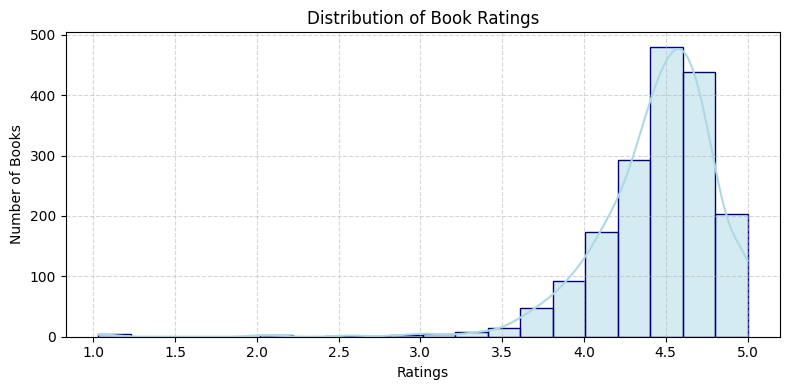

In [68]:
plt.figure(figsize=(8,4))
sns.histplot(df['rating'], bins=20, kde=True, color='lightblue', edgecolor='navy')
plt.title("Distribution of Book Ratings")
plt.xlabel("Ratings")
plt.ylabel("Number of Books")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## ✅Refleksija
Šta zaključujemo?
- Najviše knjiga ima ocene oko 4.6
- Dijagram je levo asimetričan
- Retko koja knjiga je ocenjena manje od 3.5

## 2. Zadatak
Sledeći korak je da vidimo kako se sekcije međusobno razlikuju. Ovo ćemo uraditi preko **kutijastog dijagrama**.

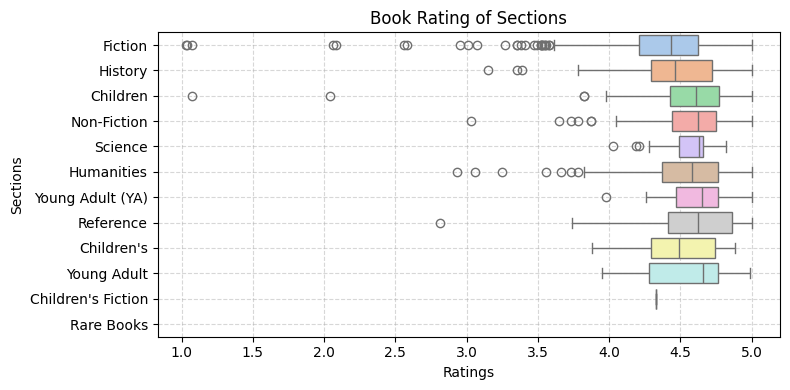

In [69]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x="rating", y="section", hue="section", palette="pastel", legend=False)
plt.title("Book Rating of Sections")
plt.xlabel("Ratings")
plt.ylabel("Sections")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## ✅Refleksija
Šta zaključujemo?
- Vidimo da i dalje ocene najviše kruže oko 4.5 (plus-minus 1) jer im je tamo medijana
- Mnogo sekcije sadrže velike ekstreme
- Normalan raspon je prosečno od 4 do 5

## 3. Zadatak
Sledeći korak je da vidimo kako su sve numeričke osobine knjiga međusobno povezane. Ovo ćemo uraditi preko **toplotne mape**.

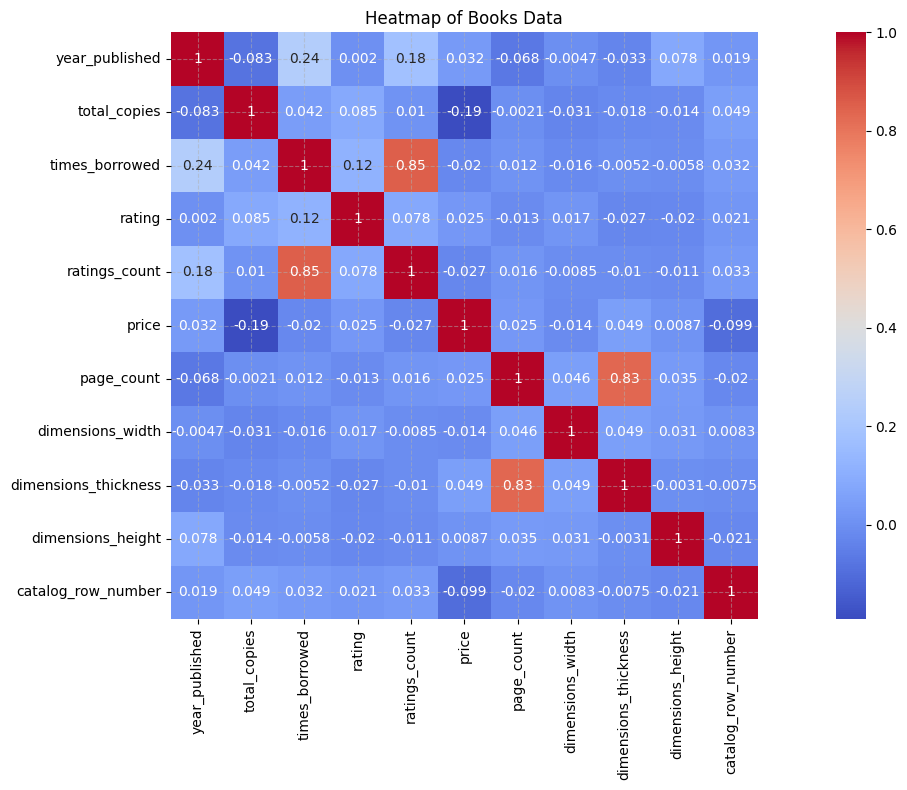

In [70]:
numeric_df = df.select_dtypes(include="number")
corr_matrix = numeric_df.corr()
plt.figure(figsize=(16,8))
sns.heatmap(data=corr_matrix, annot=True, cmap="coolwarm", square=True)
plt.title("Heatmap of Books Data")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## ✅Refleksija
Šta zaključujemo?
- Dosta podataka je nezavisno, a relacije su minimalne:
- Više pozajmljivanja - Više ocena
- Više stranica - Veća debljina knjige
- Više kopija - Manja cena

## 4. Zadatak
Sledeći korak je da vidimo kako kako karakteristike knjiga pričaju sa ocenama. Ovo ćemo uraditi preko **dijagrama rasejanja**.

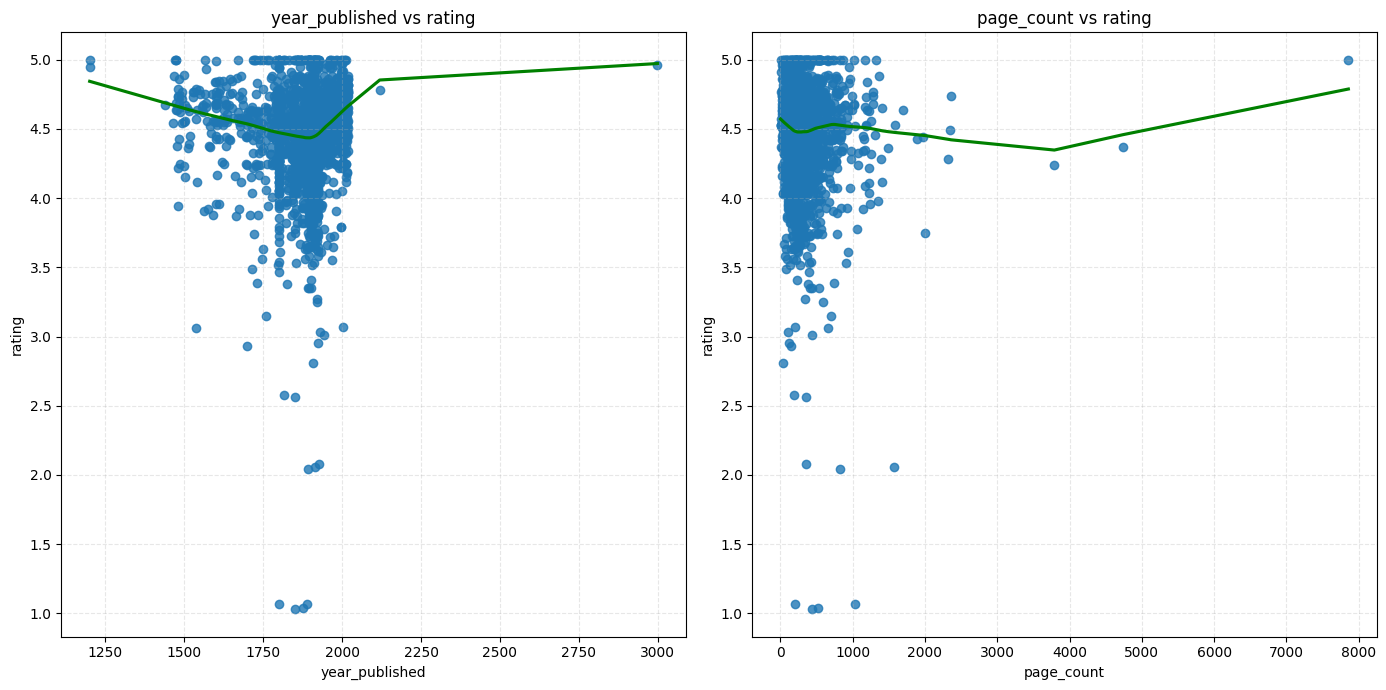

In [71]:
features = ["year_published", "page_count"]
fig, axs = plt.subplots(1, 2, figsize=(14,7))

def plot_scatter_with_trend(ax, x, y="rating"):
    sns.regplot(data=df, x=x, y=y, ax=ax, line_kws={"color": "green"}, lowess=True)
    ax.set_title(f"{x} vs {y}")
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.grid(True, linestyle="--", alpha=0.3)

for i, feature in enumerate(features):
    plot_scatter_with_trend(axs[i], feature)

plt.tight_layout()
plt.show()

## ✅Refleksija
Šta zaključujemo?
- Godina izdavanja i ocena nisu zavisne - Nekolicina ekstrema spušta prosek
- Isto važi i za broj stranica i ocene


## Zaključak zadatka
Svaka analiza treba da se uradi sa odgovorajućim dijagramom radi boljeg pregleda!
Ne znam šta više da kažem osim da je ovo čista vežba.